In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(url, names=columns)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
# Replace invalid zero values with median values
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, pd.NA)
df[cols] = df[cols].fillna(df[cols].median())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [3]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)

pred1 = model1.predict(X_test)

result1 = [
    accuracy_score(y_test, pred1),
    precision_score(y_test, pred1),
    recall_score(y_test, pred1),
    f1_score(y_test, pred1)
]

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model2 = LogisticRegression(max_iter=1000)
model2.fit(X_train_scaled, y_train)

pred2 = model2.predict(X_test_scaled)

result2 = [
    accuracy_score(y_test, pred2),
    precision_score(y_test, pred2),
    recall_score(y_test, pred2),
    f1_score(y_test, pred2)
]

In [5]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Without Scaling": result1,
    "With Scaling": result2
})

results.round(4)

,Metric,Without Scaling,With Scaling
0,Accuracy,0.7013,0.7078
1,Precision,0.5870,0.6000
2,Recall,0.5000,0.5000
3,F1-Score,0.5400,0.5455


In [6]:
from sklearn.metrics import classification_report

print("Without Scaling\n")
print(classification_report(y_test, pred1))

print("With Scaling\n")
print(classification_report(y_test, pred2))

Without Scaling

              precision    recall  f1-score   support

           0       0.75      0.81      0.78       100
           1       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

With Scaling

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



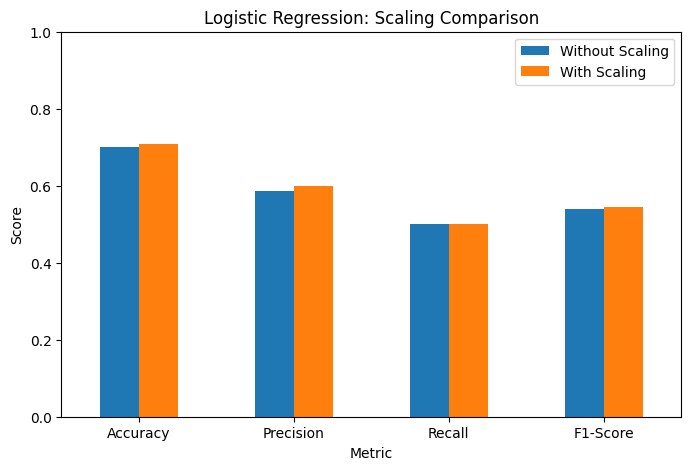

In [8]:
import matplotlib.pyplot as plt

results.set_index("Metric").plot(kind="bar", figsize=(8, 5))
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Logistic Regression: Scaling Comparison")
plt.xticks(rotation=0)
plt.show()